# Notebook 2: Studying chaotic behaviour in in elementary cellular automata

Purpose of this notebook is to give an insight into how elementary cellular automata evolve over time, with their respective rules that give place to chaotic behaviors.

Firstly, import all relevant functions from notebook "Elementary CA.ipynb"

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
from Functions_for_Notebook_1 import make_rule, make_rule_zero_condition, make_rule_symmetry #For making the rules

from Functions_for_Notebook_1 import dynamics, dynamics_reflection, dynamics_periodic #For the dynamics

from Functions_for_Notebook_1 import plot_grid #For the plotting

In this notebook we study the evolution of systems, particularly lookiong for chaotic cellular automata and ways to classify this chaos. A through literature review will be carried out.

## 1. Plotting multiple grids side to side:
We redefine the previous function such that it plots different grids side to side so that the evolution can be considered for different systems side by side. For comodity we will code such that there will be three plots tops each row.

In [3]:
def plot_grid_multiple(grids: list, cols: int):
    n = len(grids)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20 * cols, 15 * rows))
    fig.patch.set_facecolor('black')
    axes = axes.flatten()

    for i, grid in enumerate(grids):
        axes[i].imshow(grid, cmap='binary', interpolation='nearest')
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.subplots_adjust(hspace=0.5, wspace=0.001)  # vertical and horizontal spacing
    plt.show()


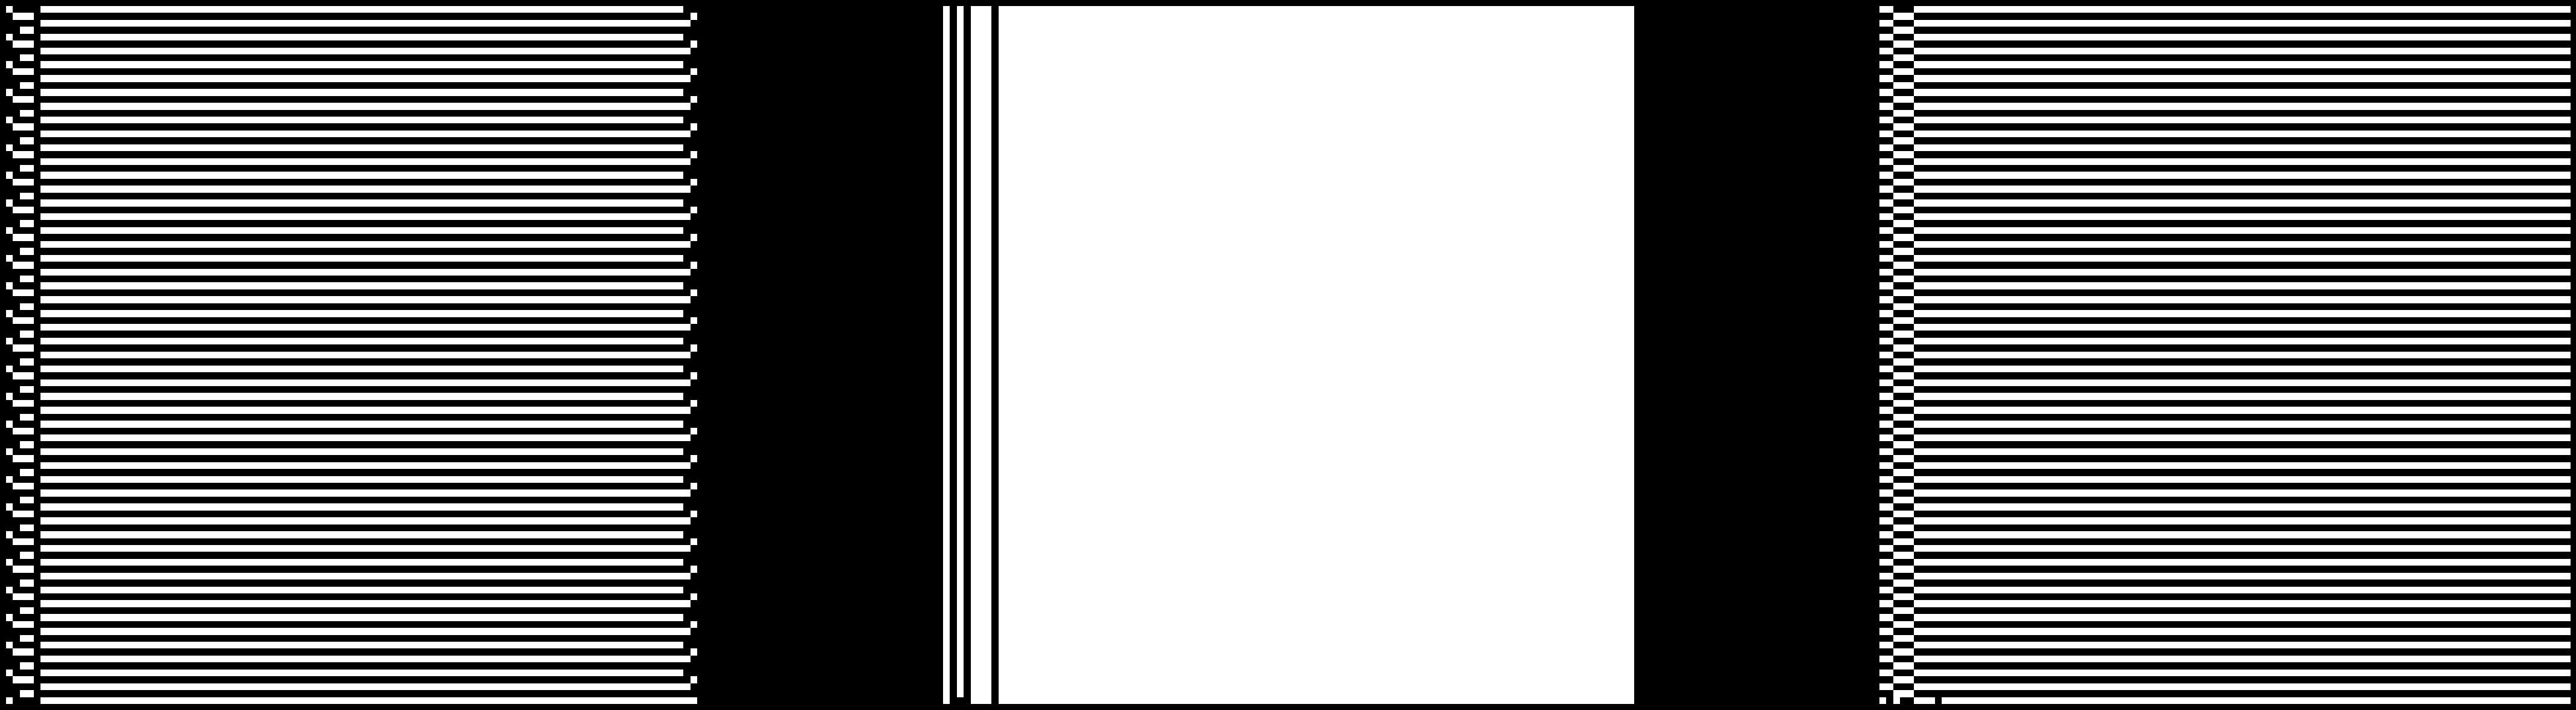

None


In [4]:
grids = (dynamics(91, 100, [1,2,3,4], 100), dynamics(76, 100, [1,2,3,7], 100), dynamics(23, 100, [1,8,3,4], 100))
print(plot_grid_multiple(grids, 3))

For example, let's code rule 11, 22 and 33 for the same initial conditions but taking symmetry, zero condition and in the standard form:

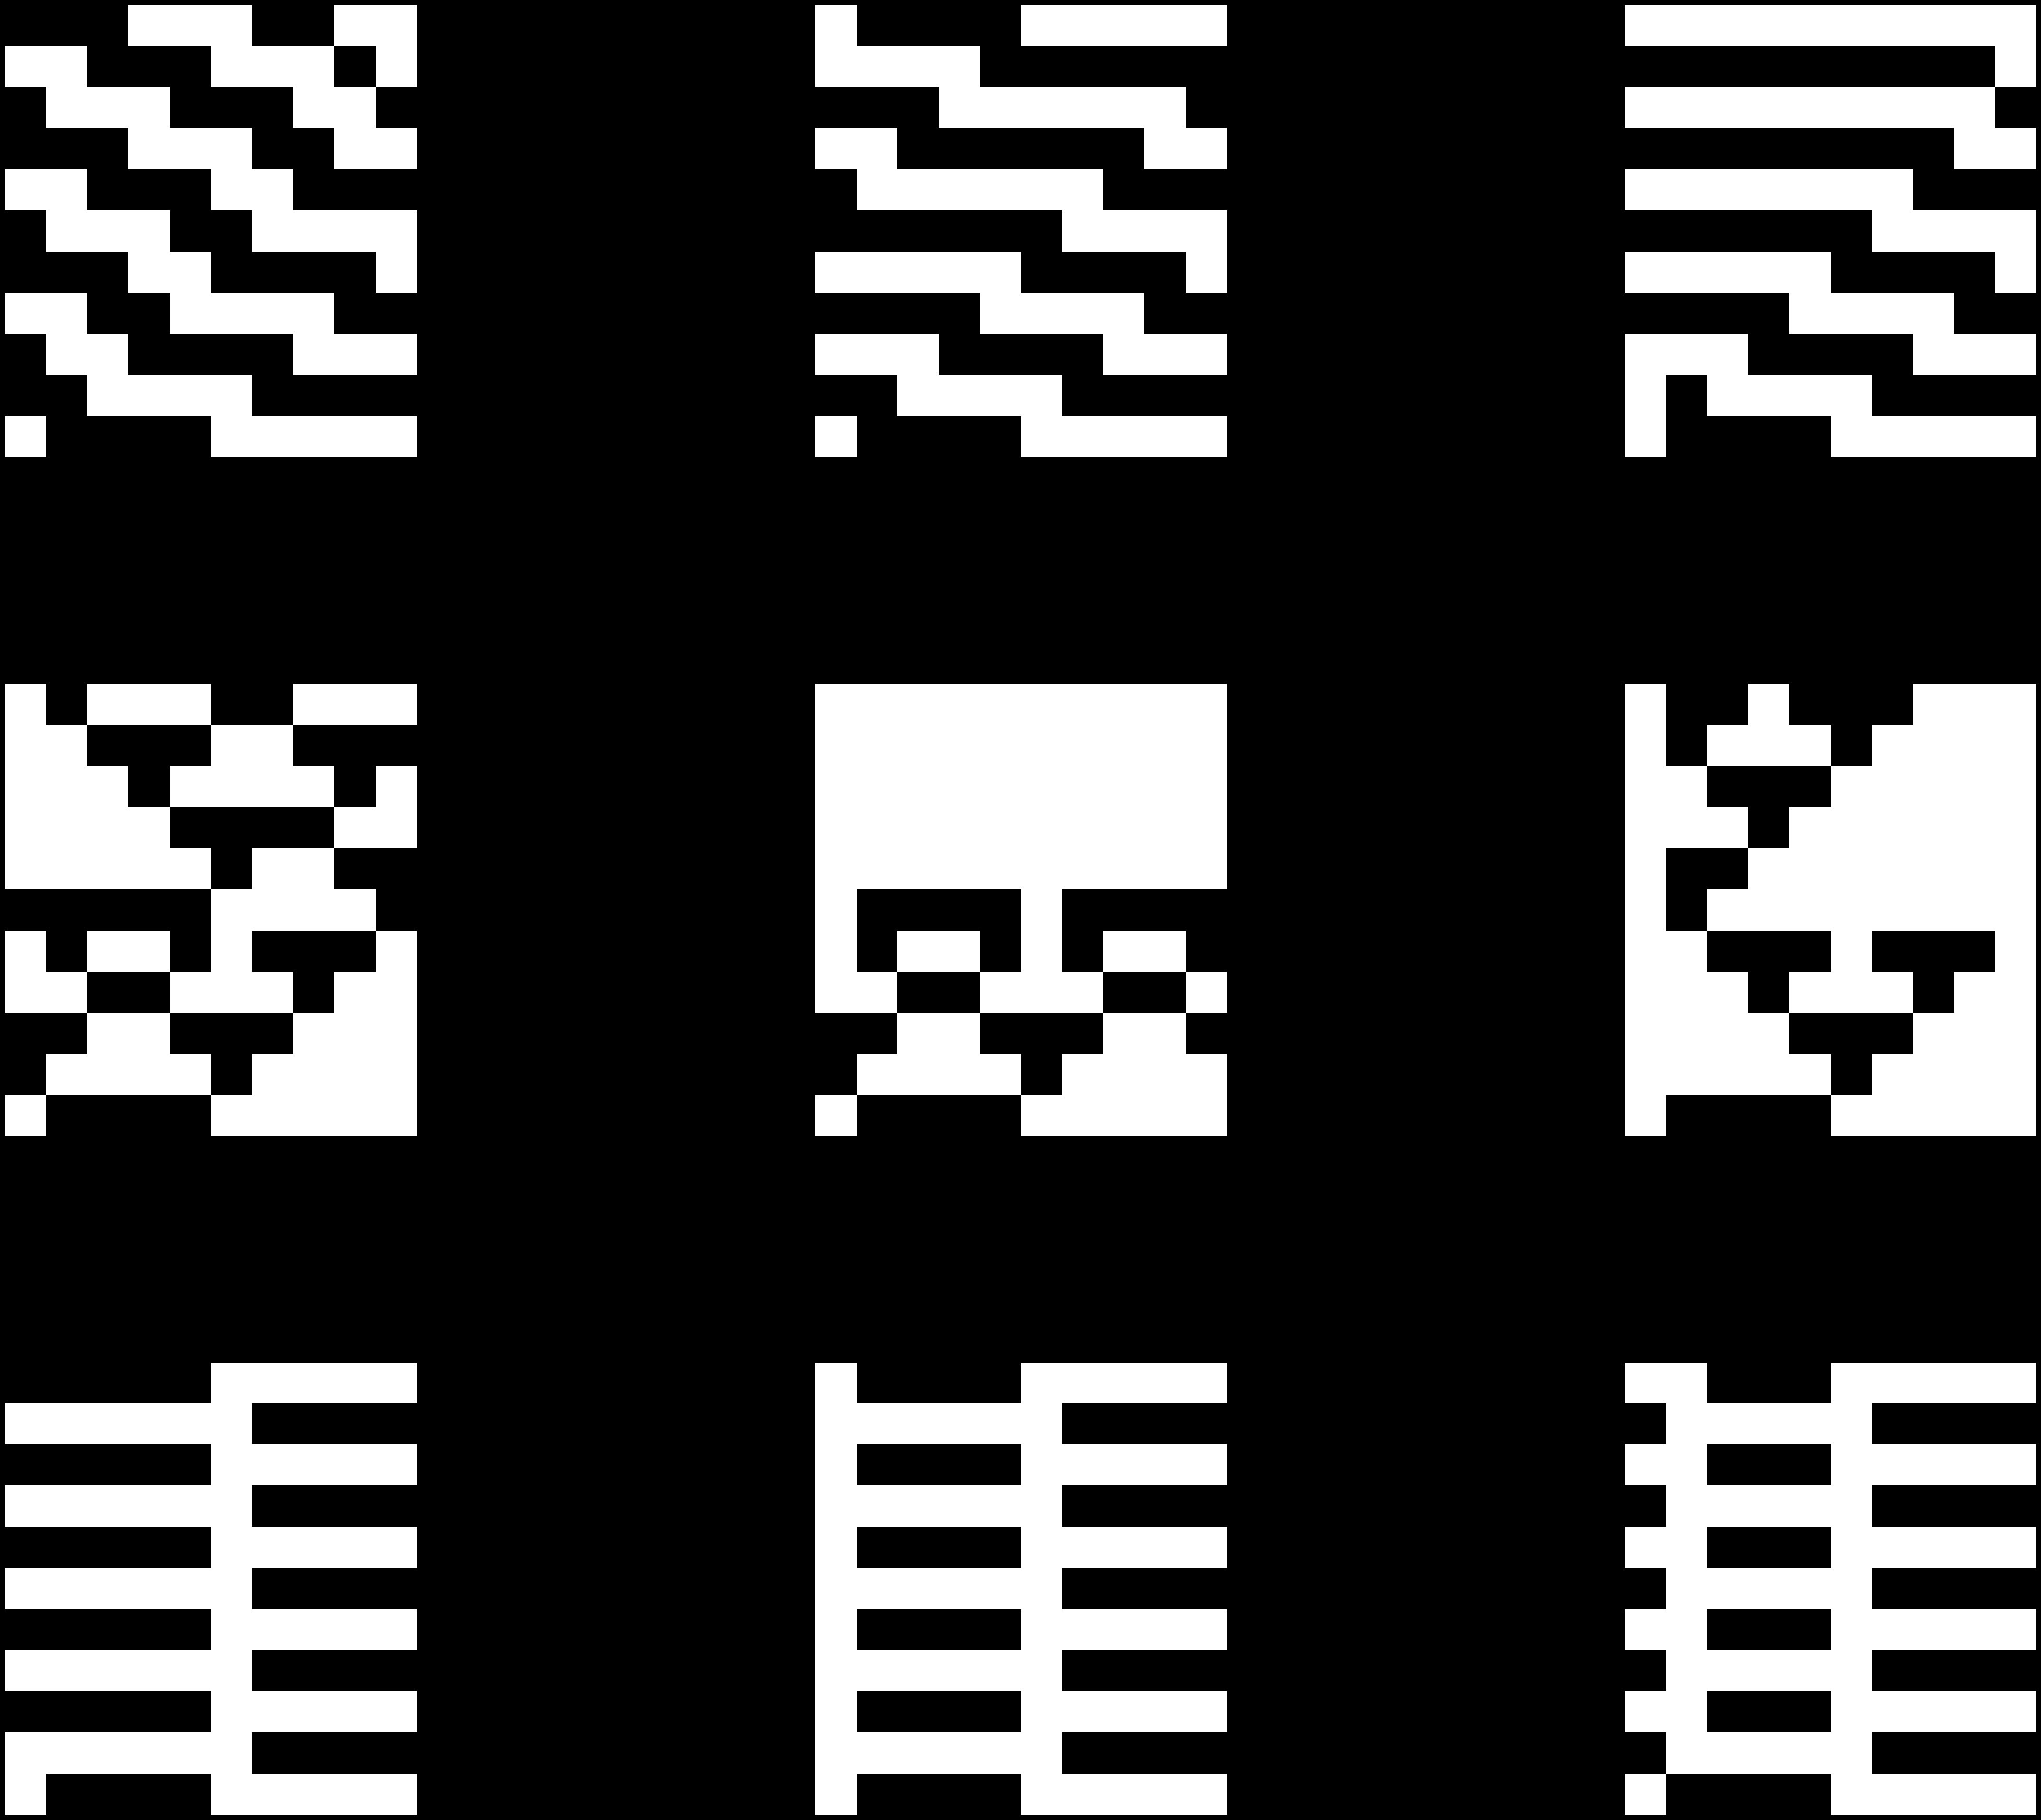

In [5]:
grids = (dynamics(11, 10, [1,2,3,4], 10), dynamics_periodic(11, 10, [1,2,3,4], 10), dynamics_reflection(11, 10, [1,2,3,4], 10),       dynamics(22, 10, [1,2,3,4], 10), dynamics_periodic(22, 10, [1,2,3,4], 10), dynamics_reflection(22, 10, [1,2,3,4], 10),       dynamics(33, 10, [1,2,3,4], 10), dynamics_periodic(33, 10, [1,2,3,4], 10), dynamics_reflection(33, 10, [1,2,3,4], 10))
plot_grid_multiple(grids, 3)

## 2. Examples and functions for chaotic grids

### 2.1) Rule 30 and functions for chaotic grids

It is known from literature that rule 30 is chaotic, meaning the final cell is highly susceptible to the initial cell's initial conditions. Let's plot it six times where one of the iniutial conditions is changed just once:

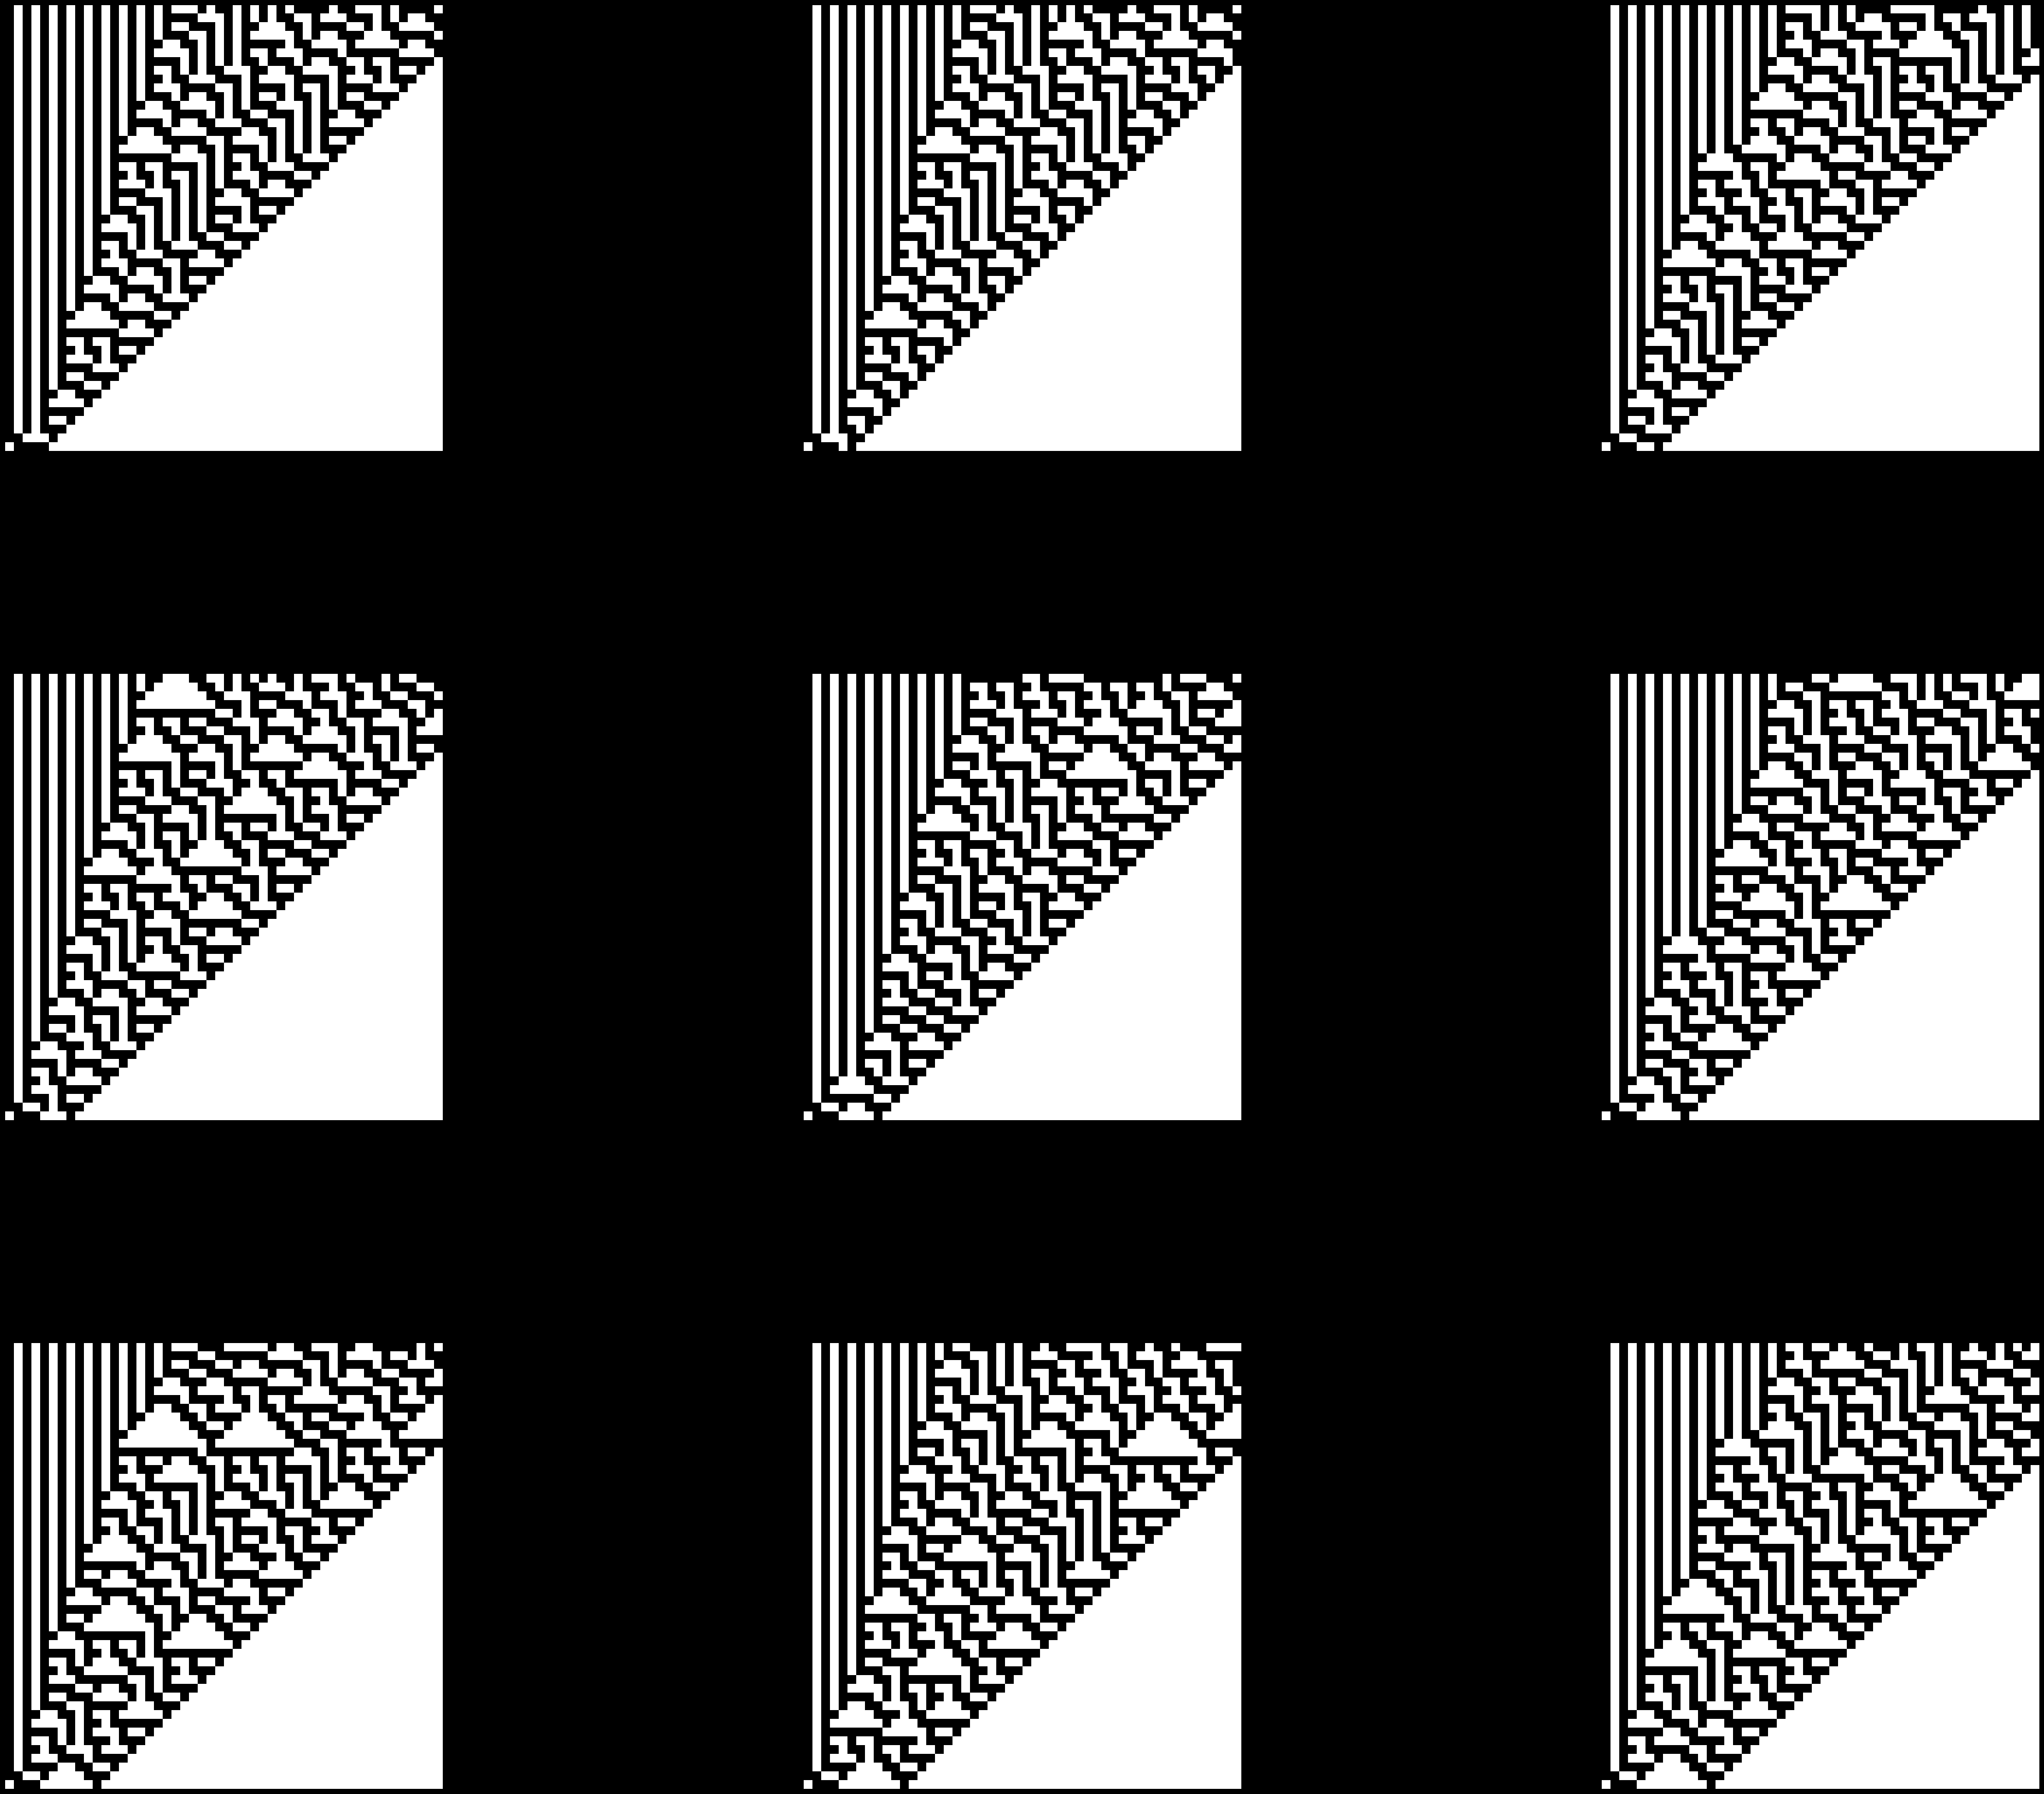

In [6]:
i=4
grids = (dynamics(30, 50, [1,2,3,i], 50), dynamics(30, 50, [1,2,3,i+1], 50), dynamics(30, 50, [1,2,3,i+2], 50),       dynamics(30, 50, [1,2,3,i+3], 50), dynamics(30, 50, [1,2,3,i+4], 50), dynamics(30, 50, [1,2,3,i+5], 50),       dynamics(30, 50, [1,2,3,i+6], 50), dynamics(30, 50, [1,2,3,i+7], 50), dynamics(30, 50, [1,2,3,i+8], 50))
plot_grid_multiple(grids, 3)

Because at such large scales it is hard to predict the chaos of the system, we can instead opt to redefine the function for the dynamics such that it only prints out the first and last cell, so the initial and final state of the system.

In [7]:
def dynamics_initialandfinal(rule_number, L, initial_conditions, timesteps):
    # Building up the lookup table
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropiate")
    
    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)
    for i in initial_conditions:
        row[i] = 1
    rows = [row.copy()] #So we take an independent "snapshot"

    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j - 1])) if j > 0 else '0'       # zero boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j + 1])) if j < L - 1 else '0'   # zero boundary
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    
    return rows[0], "->", rows[-1]

In [8]:
print(dynamics_initialandfinal(34, 10, [1,3,5,7,9], 3), "\n", dynamics_initialandfinal(34, 10, [1,3,5,7,9], 10))

(array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1]), '->', array([1, 0, 1, 0, 1, 0, 1, 0, 0, 0])) 
 (array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1]), '->', array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))


As a different approach, we can take a function that counts the number of cells for two grids of the same size that have different values.

We start defining the function the following way:

In [9]:
def state_comparison(system_1, system_2):
    if system_1.shape != system_2.shape:
        raise ValueError("Systems must be of the same size")
    
    j = np.sum(system_1 != system_2)
    n = system_1.size
    
    return (j, j / n)

For two systems that are equal, the output must be zero.

In [10]:
system_1 = dynamics(3,10, [1,4,6], 10)
system_2 = system_1

print(state_comparison(system_1, system_2)) #Checks out

(0, 0.0)


In [11]:
system_1 = dynamics(89, 50, [10, 20, 30, 40, 49], 50)
system_2 = dynamics(89, 50, [11, 20, 30, 40, 49], 50)
system_1.shape[0]

print(state_comparison(system_1, system_2))

(530, 0.20784313725490197)


We can define a different function to only do this for a certain row or column at a guven timestep. To compare a certain column or row, axis = 1 corresponds columns and axis = 0 corresponds to rows. 

It is relevant to mention that for rows that the inital conditions will have for index the last possible number, so it is important to consider this in the function such that the input timestep=0 prints out the first row.


In [12]:
def state_comparison_slice(system_1, system_2, timestep, axis):
    if axis == 1:
        i = timestep
        slice_1 = system_1[:, i]
        slice_2 = system_2[:, i]
    else:
        i = system_1.shape[0]-1-timestep
        slice_1 = system_1[i, :]
        slice_2 = system_2[i, :]

    if len(slice_1) != len(slice_2):
        raise ValueError("Systems must be of the same size")

    j = np.sum(slice_1 != slice_2)
    return ( j, j / len(slice_1))

For these initila conditions, the second one's is the first one's plus another one at 25:

In [13]:
system_1 = dynamics(30, 50, [10, 20, 25, 30, 40, 49], 50)
system_2 = dynamics(30, 50, [10, 20, 30, 40, 49], 50)

In [14]:
print(state_comparison_slice(system_1, system_2, 0, axis=0))

(1, 0.02)


Looking at the last row, determine the number of cells that are different:

In [15]:
print(state_comparison_slice(system_1, system_2, 50, axis=0)) 

(21, 0.42)


It is expected for this value to approach 50% (25), as will be seen later.

Another example is:

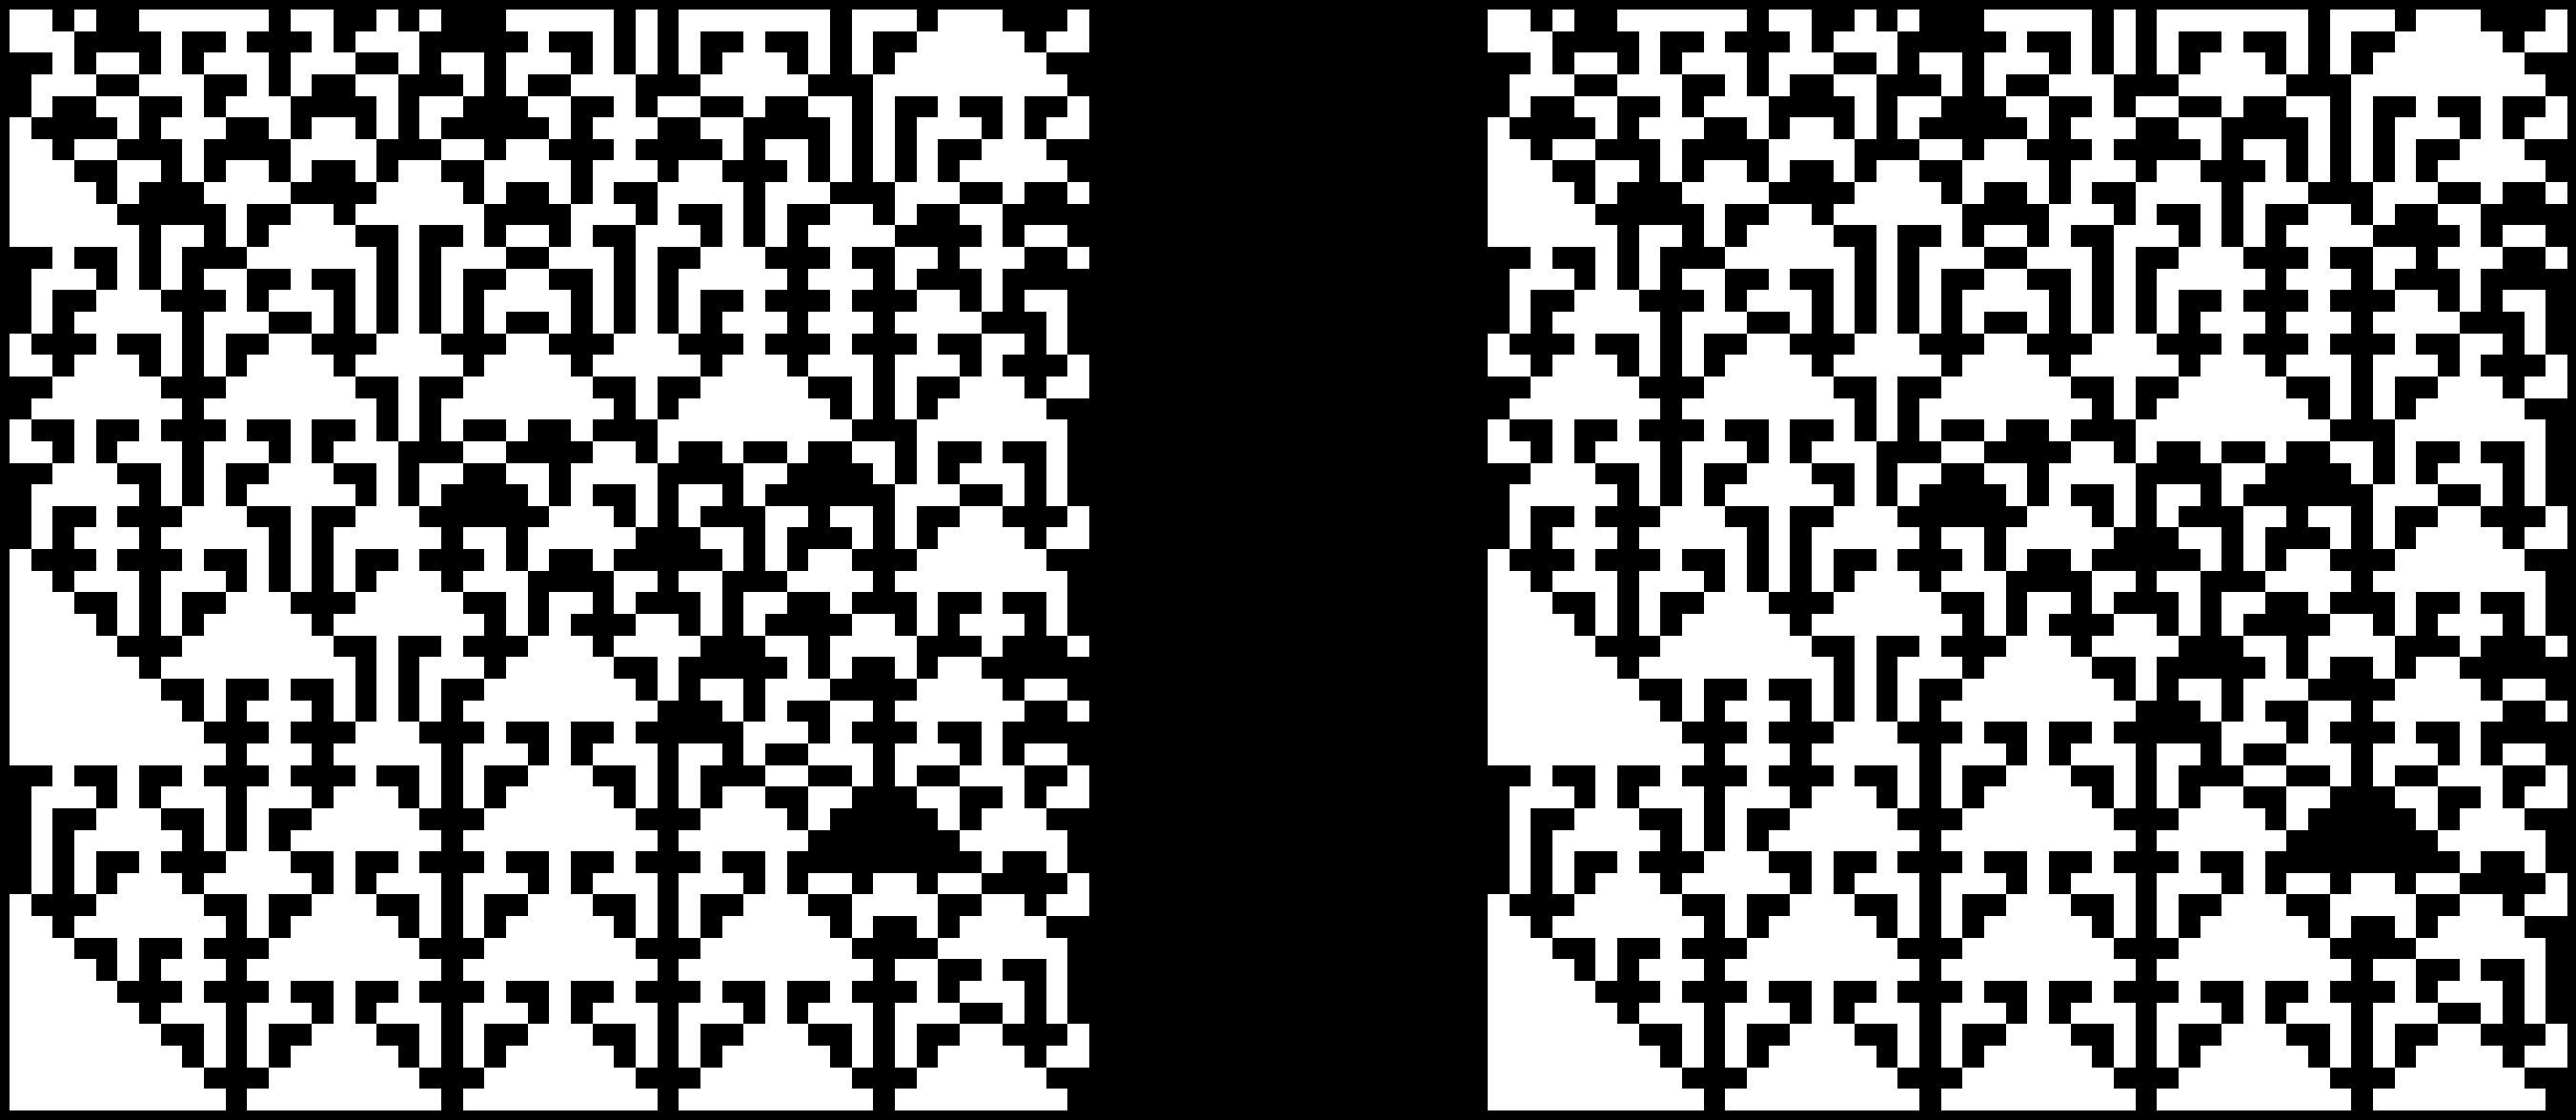

(19, 0.37254901960784315)


In [16]:

system_1 = dynamics(150, 50, [10, 20, 30, 40, 49], 50)
system_2 = dynamics(150, 50, [10, 22, 29, 40, 49], 50)

states = system_1, system_2

states = dynamics(150, 50, [10, 20, 30, 40, 49], 50), dynamics(150, 50, [10, 20, 30, 40, 49], 50)

plot_grid_multiple(states, 2)

print(state_comparison_slice(system_1, system_2, 23, axis = 1)) #The twenty-third timestep

This code to determine how many cells are different between two systems can help distinguish chaos or other types of evolution.

### 2.2) Study of columns

A function can be determined to plot a column so the time evolution of a single cell can be studied in time:

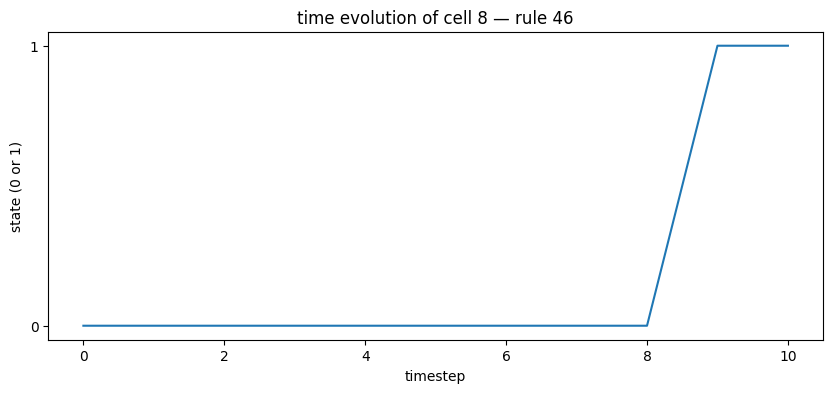

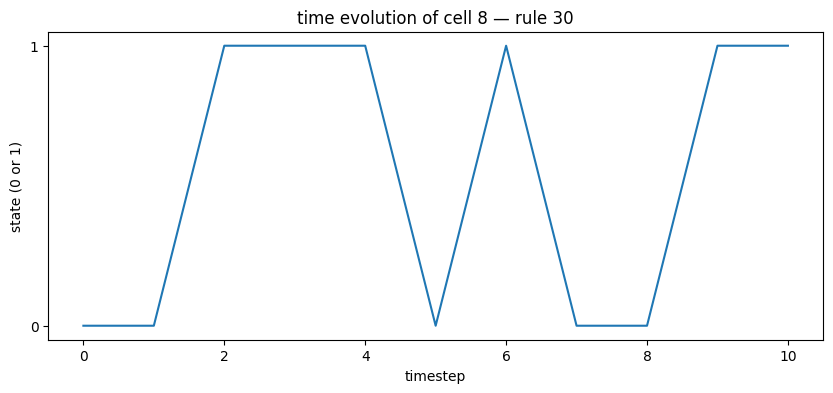

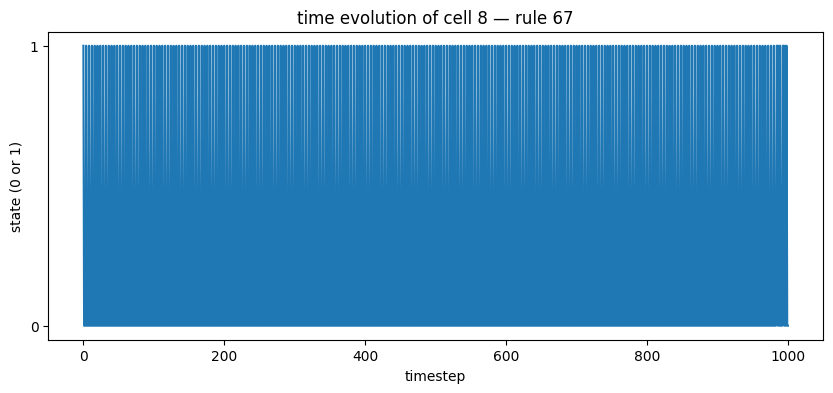

In [17]:
def plot_cell(rule, cell_i, timesteps, L):
    initial_conditions = np.random.randint(0, 2, size=L)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, L, row, timesteps)
    
    cell = system[:, cell_i]  
    
    plt.figure(figsize=(10, 4))
    plt.plot(cell)
    plt.xlabel('timestep')
    plt.ylabel('state (0 or 1)')
    plt.title(f'time evolution of cell {cell_i} — rule {rule}')
    plt.yticks([0, 1])
    plt.show()

plot_cell(46, 8, 10, 10)
plot_cell(30, 8, 10, 10)
plot_cell(67, 8, 1000, 1000)

To make it more visual:

In [18]:
def plot_column(arr, col, cols=100):
    column = arr[:, col] if arr.ndim > 1 else arr
    n = len(column)

    def render_segment(seg, start_t):
        print(f'{"":7}┌─┐')
        for i, x in enumerate(seg):
            t = start_t + i
            dead = '█' if (t + col) % 2 == 0 else "□"  
            print(f't={t:<4} │{"□" if x else dead}│')
        print(f'{"":7}└─┘')

    segments = [column[i:i+cols] for i in range(0, n, cols)]
    for idx, seg in enumerate(segments):
        render_segment(seg, idx * cols)
        if idx < len(segments) - 1:
            print()

An example with a given system:

In [19]:
system = dynamics(43, 30, [2,6,24], 30)
plot_column(system, col = 3, cols = 3)

       ┌─┐
t=0    │□│
t=1    │█│
t=2    │□│
       └─┘

       ┌─┐
t=3    │□│
t=4    │□│
t=5    │█│
       └─┘

       ┌─┐
t=6    │□│
t=7    │█│
t=8    │□│
       └─┘

       ┌─┐
t=9    │□│
t=10   │□│
t=11   │█│
       └─┘

       ┌─┐
t=12   │□│
t=13   │█│
t=14   │□│
       └─┘

       ┌─┐
t=15   │□│
t=16   │□│
t=17   │█│
       └─┘

       ┌─┐
t=18   │□│
t=19   │█│
t=20   │□│
       └─┘

       ┌─┐
t=21   │□│
t=22   │□│
t=23   │█│
       └─┘

       ┌─┐
t=24   │□│
t=25   │█│
t=26   │□│
       └─┘

       ┌─┐
t=27   │□│
t=28   │□│
t=29   │█│
       └─┘

       ┌─┐
t=30   │□│
       └─┘


To plot multiple cells on the same plot so that you can regard the evolution of multiple cells at the same time (specially useful if they are neighbors):

In [20]:
def plot_multiple_cells(*cells):
    fig, ax = plt.subplots(figsize=(10, 4))

    for rule, initial_conditions, timesteps, L, cell_i in cells:
        system = dynamics(rule, L, initial_conditions, timesteps)

        ax.plot(system[:, cell_i], label=f'rule {rule} — cell {cell_i}')

    ax.set_xlabel('timestep')
    ax.set_ylabel('state (0 or 1)')
    ax.set_yticks([0, 1])
    ax.legend()
    plt.tight_layout()
    plt.show()

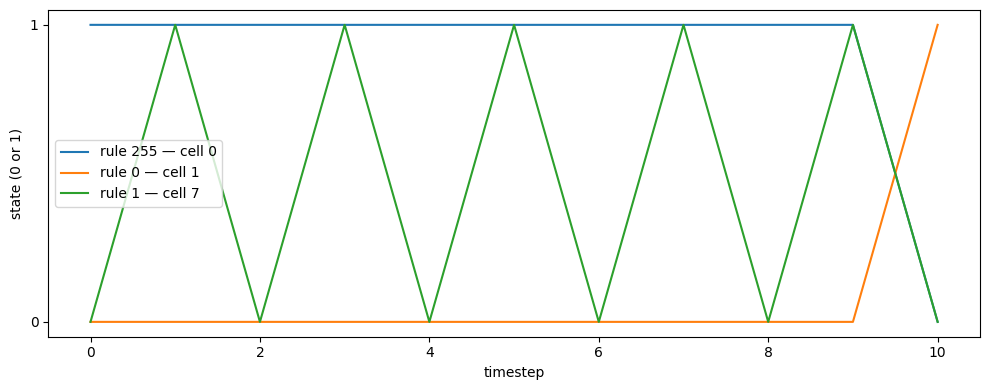

In [21]:
cell_1 = (255, [1,2,3], 10, 9, 0)
cell_2 = (0, [1,0,0], 10, 9, 1)
cell_3 = (1, [0,2,3], 10, 9, 7)

plot_multiple_cells(cell_1, cell_2, cell_3)

# (rule, cell_i, timesteps, L)

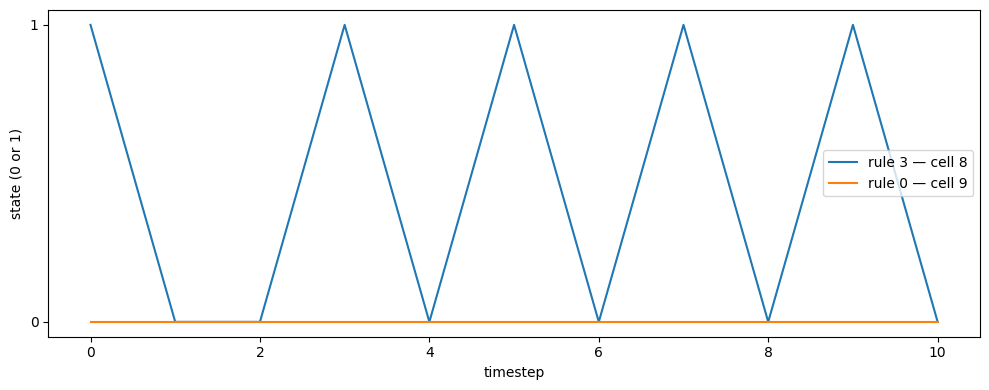

In [22]:
cell_4 = (3, [0,2,3], 10, 10, 8)
cell_5 = (0, [0,2,3], 10, 10, 9)

plot_multiple_cells(cell_4, cell_5)

## 3. Ways to classify behaviours of cellular automata

### 3.1) Stephen Wolfram's classes:

Stephen Wolfram distinguished four distinct classes of cellular automata based on their long term behaviour ("A New Kind of Science" (2002)):
- Class I: Converges to a uniforms state(oppossite of chaotic): Regardles of the initial conditions, it will converge to the same final state, so over a large time initial.
- Class II: Converges to periodic / stable structures
- Class III (chaotic): Converges to randomness / noise
- Class IV (complex, edge between order and chaos): Has a heterogeneous structure.

#### 3.1.1) Class I

A function can be determined to regard if a rule corresponds to class 1, it takes a 1000x1000 grid with a given rule and plots the system, then the system is another time such that all the plots are plotted with random initial conditions. 

If the number of cells for the last stage is less than 10% of the total cells at that stage, then it is classified as class I.

In [23]:
def rule_1(rule):
    initial_conditions_1 = np.random.randint(0, 2, size=1000)
    initial_conditions_2 = np.random.randint(0, 2, size=1000)
    system_1 = dynamics(rule, 1000, initial_conditions_1, 1000)
    system_2 = dynamics(rule, 1000, initial_conditions_2, 1000)

    if state_comparison_slice(system_1, system_2, 999, axis=0)[1] <= 0.1:
        return True
    else:
        return False

Rule 0, 8 and 32 converge to all zero, so they are class 1:

In [24]:
print(rule_1(8), rule_1(160), rule_1(32))

print(rule_1(250)) #Converges to all 1

True True True
True


Rule 204, 232 and 108 converge to stable patterns:

In [25]:
print(rule_1(204), rule_1(232), rule_1(108))

True True True


#### 3.1.2) Class III

In the case of chaotic cellular automata, they converge to a random state, so the fucntion that determines if a rule is of class III will look at the cells that are different for the same rule and similar initial conditions in the final timestep and if the propotionality of cells that are different to total number of cells is contained between 40 and 60% (ideally 50%), the rule is chaotic.

In [26]:
def rule_3(rule): # Works not perfectly
    initial_conditions_1 = np.random.randint(0, 2, size=1000)
    initial_conditions_2 = initial_conditions_1.copy()
    i = random.randint(0, 999)
    if initial_conditions_1[i] == 1:
        initial_conditions_1[i] = 0
    else:
        initial_conditions_1[i] = 1

    row_1 = list(np.where(initial_conditions_1 == 1)[0])
    row_2 = list(np.where(initial_conditions_2 == 1)[0])

    system_1 = dynamics(rule, 1000, row_1, 1000)
    system_2 = dynamics(rule, 1000, row_2, 1000)
    
    # row 0 is the final timestep due to reversal in dynamics. Very important
    vals = [np.sum(system_1[i] != system_2[i]) / 1000 for i in range(0, 100)]
    val = np.mean(vals)

    return 0.25 <= val <= 0.75, val

In [27]:
chaotic_rules = [30, 45, 86, 126, 135, 149, 182]

for rule in chaotic_rules:
    result, val = rule_3(rule)
    print(f"rule {rule:3d}: {result}, val={val:.3f}")

rule  30: False, val=0.171
rule  45: True, val=0.415
rule  86: True, val=0.302
rule 126: True, val=0.503
rule 135: True, val=0.316
rule 149: True, val=0.314
rule 182: True, val=0.349


Rules 30, 45 and 150 are known to be chaotic:

#### 3.1.3) Class II
For class II, we can use the fucntion defined earlier for measuring the total number of cells acros the whole grid that are different. Under 10% of cells should be different if it is class II, because it gives place to stable periodic structures.

In [28]:
def rule_2(rule): 
    initial_conditions_1 = np.random.randint(0, 2, size=1000)
    initial_conditions_2 = initial_conditions_1.copy()
    i = random.randint(0, 999)
    if initial_conditions_1[i] == 1:
        initial_conditions_1[i] = 0
    else:
        initial_conditions_1[i] = 1

    row_1 = list(np.where(initial_conditions_1 == 1)[0])
    row_2 = list(np.where(initial_conditions_2 == 1)[0])

    system_1 = dynamics(rule, 1000, row_1, 1000)
    system_2 = dynamics(rule, 1000, row_2, 1000)

    if system_1.shape != system_2.shape:
        raise ValueError("Systems must be of the same size")
    
    j = np.sum(system_1 != system_2)
    n = system_1.size

    if j/n <=0.1:
        return True
    else:
        return False

Rules 4, 12 and 36 are class 2:

In [29]:
print(rule_2(4), rule_2(12),rule_2(36))

True True True


#### 3.1.4) Class IV
Rule IV is the most difficult to detect because it requires more steps for the evolution to be distinguishable from class II, so it requires more computational power and is too dificult to distinguish the same way as the otehr classes. However, it can be distinguished when it doesn't belong to any of the otehr three rules.

In [30]:
def is_rule(rule):
    if rule_1 == True:
        return "Class I"
    elif rule_2 == True:
        return "Class II"
    elif rule_3 == True:
        return "Class III"
    else:
        return "Class IV"

### 3.2) Information-theoretic measures:
Classical information theory measures how much information is in a system and how it flows in classical systems.

Sources: 
- 1. Crutchfield & Young, "Inferring Statistical Complexity", Physical Review Letters (1989)

- 2. Shannon, C.E. (1948). "A Mathematical Theory of Communication." Bell System Technical Journal, 27, 379-423.

#### Entropy
Entropy measures how unpredictable the states are, an entropy of zero means individual cells are perfectly predictable and an entropy of one (maximum) means there is no way of predicting the evolution of the cells.

The mathematical definition of Shannon entropy:
H = -Σ p(x) log₂ p(x)


In [31]:
from scipy.stats import entropy as automatic_entropy

In [32]:
def H_CA(rule): #Take an empirical probability approach, this is the entrpy of the system at each timestep
    initial_conditions = np.random.randint(0, 2, size=1000)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, 1000, row, 1000)
    entropies_at_each_timestep = []
    for t in range(1000):
        p1=np.mean(system[t])
        p0 = 1 - p1
    
        if p0 == 0 or p1 == 0:
            entropies_at_each_timestep.append(0)
        else:
            h = -p0 * np.log2(p0) - p1 * np.log2(p1)
            entropies_at_each_timestep.append(h)

    return entropies_at_each_timestep 

print(H_CA(200))

def H_cell(rule, location): #Evolution of the single cell across the timeseries
    initial_conditions = np.random.randint(0, 2, size=1000)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, 1000, row, 1000)
    
    cell = system[:, location]

    p1 = np.mean(cell)
    p0 = 1 - p1
    
    if p0 == 0 or p1 == 0:
        return 0
    
    return -p0 * np.log2(p0) - p1 * np.log2(p1)



[0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385, 0.9179621399872385,

#### Mutual information
How much information knowing the cell i gives on the cell j:
- Class I: Zero because all cells are identical and offer no information content (too ordered).
- High: Because patterns and structures are formed.
- Class III: Zero, cells are completely random (too chaotic).
- Class IV: High because structured patters emerge, meaning correlation.

The mathematical definition of mutual information in classical information theorty is:

I(X;Y) = Σ Σ p(x,y) log₂ p(x,y) / (p(x) p(y))

but also:

I(X;Y) = H(X) + H(Y) - H(X,Y)

The second one will be used for the definition. We will take X as one cell and Y as its neighboring cell, we'll take the right as convention.

The mathematical definition of entropy is the following:

H(X,Y) = -Σ Σ p(x,y) log₂ p(x,y)

The output value lies between 0 and 2, the lower the value the higher the predictability and vice versa. A value of zero means the two cells are the same or at least have the same evolution.

In [33]:
def H_two_cells(rule, cell_i, cell_j):
    initial_conditions = np.random.randint(0, 2, size=L)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, 1000, row, 1000)
    
    x = system[:, cell_i]  # time series of cell i
    y = system[:, cell_j]  # time series of cell j
    
    # joint probabilities
    p11 = np.mean((x == 1) & (y == 1))
    p00 = np.mean((x == 0) & (y == 0))
    p10 = np.mean((x == 1) & (y == 0))
    p01 = np.mean((x == 0) & (y == 1))
    
    # joint entropy
    h = 0
    for p in [p00, p01, p10, p11]:
        if p > 0:
            h -= p * np.log2(p)
    
    return h

The work of the three functions can be used to obtain the mutual information:

In [34]:
def mutual_information(rule, cell_i, cell_j):
    try:
        cell_j = cell_i+1
    except:
        cell_j = cell_i-1
    
    ic = np.random.randint(0, 2, size=L)
    row = list(np.where(ic == 1)[0])
    system = dynamics(rule, 1000, row, 1000)
    
    x = system[:, cell_i]  # time series of cell i
    y = system[:, cell_j]  # time series of cell j
    
    H_x = H_cell(rule, cell_i)
    H_y = H_cell(rule, cell_j)
    H_xy = H_two_cells(rule, cell_i, cell_j)
    
    return H_x + H_y - H_xy  

The output value for the mutual information lies between 0 and 1 and the lower the value the more independence and less one tells you about the other and vice versa.

#### Excess entropy or effective complexity:
Excess entropy measures how much structured, non-random information exists in the system. It does noit include nor noise nor trivial information:
- Class I: Zero because the system converges regardless of initial conditions.
- Class II: Low because the information can be "Traced back" due to predictability, but it is all trivial information.
- Class III: Zero because the system ends up converging to randomness.
- Class IV: High because the past patially predicts the future in a non trivial way.

The mathematical description is the following:

E = I(past ; future), so the previous function for mutual information can be used.

The approach taken is dividing the timesteps into two and seeing how much the first half predicts the second half. Because we are comparing two sequences in the same space with different time, as oppossed to earlier where it was two different cells in space within the same timeframe.

In [ ]:
def H_cell_EC(rule, cell_i, array=None): ### EC for effective complexity
    if array is not None:
        cell = array
    else:
        initial_conditions = np.random.randint(0, 2, size=1000)
        row = list(np.where(initial_conditions == 1)[0])
        system = dynamics(rule, 1000, row, 1000)
        cell = system[:, cell_i]
    
    p1 = np.mean(cell)
    p0 = 1 - p1
    if p0 == 0 or p1 == 0:
        return 0
    return -p0 * np.log2(p0) - p1 * np.log2(p1)


def H_two_cells_EC(rule, cell_i, cell_j, array_x=None, array_y=None):
    if array_x is not None and array_y is not None:
        x, y = array_x, array_y
    else:
        initial_conditions = np.random.randint(0, 2, size=1000)
        row = list(np.where(initial_conditions == 1)[0])
        system = dynamics(rule, 1000, row, 1000)
        x = system[:, cell_i]
        y = system[:, cell_j]
    
    p11 = np.mean((x == 1) & (y == 1))
    p00 = np.mean((x == 0) & (y == 0))
    p10 = np.mean((x == 1) & (y == 0))
    p01 = np.mean((x == 0) & (y == 1))
    
    h = 0
    for p in [p00, p01, p10, p11]:
        if p > 0:
            h -= p * np.log2(p)
    return h

In [ ]:
def effective_complexity(rule):
    L = 500
    timesteps = 1000

    initial_conditions = np.random.randint(0, 2, size=L)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, L, row, timesteps)

    initial = system[0, :]   # state of all cells at t=0
    final   = system[-1, :]  # state of all cells at t=999

    H_initial = H_cell_EC(rule, 0, array=initial)
    H_final   = H_cell_EC(rule, 0, array=final)
    H_joint   = H_two_cells_EC(rule, 0, 0, array_x=initial, array_y=final)

    return H_initial + H_final - H_joint

In [37]:
for rule in [0, 4, 30, 110]:
    print(f"rule {rule}: E = {effective_complexity(rule):.3f}")

rule 0: E = 0.000
rule 4: E = 0.166
rule 30: E = 0.001
rule 110: E = 0.002


We continuosly get all zeros, so a difrerent option is to average over the evolution of all cells, instead of one, since effective complexity should depend on the rule itself and have nothing to do with the cell randomly chosen. 

In [38]:
def effective_complexity(rule):
    L = 500
    timesteps = 1000

    initial_conditions = np.random.randint(0, 2, size=L)
    row = list(np.where(initial_conditions == 1)[0])
    system = dynamics(rule, L, row, timesteps)
    
    mi_values = []
    for cell_i in range(L):
        past   = system[1:501, cell_i]
        future = system[501:, cell_i]

        H_past   = H_cell(rule, cell_i, array=past)
        H_future = H_cell(rule, cell_i, array=future)
        H_joint  = H_two_cells(rule, cell_i, cell_i, array_x=past, array_y=future)

        mi_values.append(H_past + H_future - H_joint)

    return np.mean(mi_values)

In [39]:
for rule in [0, 4, 30, 110]:
    print(f"rule {rule}: E = {effective_complexity(rule):.3f}")

rule 0: E = 0.000
rule 4: E = 0.000
rule 30: E = 0.001
rule 110: E = 0.010


Rule 110 shoudl give the highest value gut gives a value of none, which may be necause across a 1000 timestspes it looks random, there are issues for universally using this method for all cells, however it does seem to correctly classify classes 1,2 and 3.

#### 3.2.1) Classifying systems with concepts from information theory

Effective complexity gives the most complete description of how a cell in a grid voñves over abguven time, piinting to its general behaviour and allowing for comparisons with Wolfram's classes.

### 3.3) Dynamical measures:

Source: Bagnoli et al., "Damage Spreading and Lyapunov Exponents in Cellular Automata", Physics Letters A (1992)

Additionally, cellular automata can also be modeled using the theory of dynamical systems. Cellular automata are discrete dynamical systems in both space and time.

#### 3.3.1) Lyapunov exponent
In continuos dynamical systems, the Lyaponov exponent measures how fast nearby trajectories diverge, in CA the analogue is how fast perturbation spreads. It relies on a concept called damage.

Damage: Difference in the evolution of a system after slightly changing the initial conditions. Specifically, it measures the number of cells that are different, which is what previous lines of code have done. 

The Lyapunov exponent is given by the following formula:

λ ≈ (1/t) ln(damage(t) / damage(0))

Because in this case the initial damage is 1:

λ ≈ (1/t) ln(damage(t)) 

In [40]:
def damage(rule):
    initial_conditions_1 = np.random.randint(0, 2, size=1000)
    initial_conditions_2 = initial_conditions_1.copy()
    i = random.randint(0, 999)
    if initial_conditions_1[i] == 1:
        initial_conditions_1[i] = 0
    else:
        initial_conditions_1[i] = 1

    row_1 = list(np.where(initial_conditions_1 == 1)[0])
    row_2 = list(np.where(initial_conditions_2 == 1)[0])

    system_1 = dynamics(rule, 1000, row_1, 1000)
    system_2 = dynamics(rule, 1000, row_2, 1000)
    
    dmg = np.array([np.sum(system_1[t] != system_2[t]) for t in range(1, 1000)])
    mean = np.mean(dmg)

    variance = np.var(dmg)
    return dmg, mean, variance

def lyapunov_exponent(rule):
    early = damage[:20] # Take early sample to avoid saturation
    early = early[early > 0] # Avoid log of 0
    t = np.arange(1, len(early) + 1)
    exponent = np.mean(np.log(early) / t)
    return exponent #Usually represented by a lambda symbol

print(damage(30)[1])

63.828828828828826


Plotting damage across time:

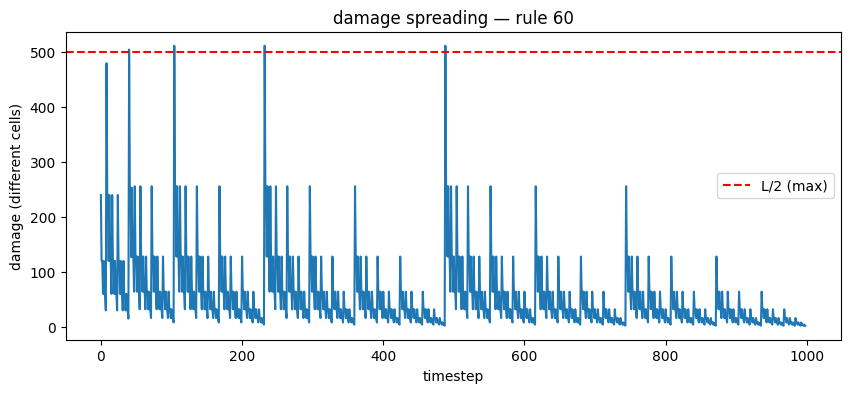

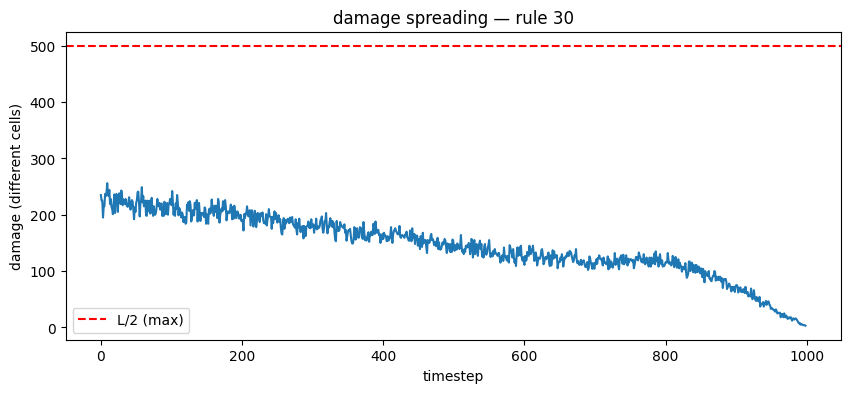

In [41]:
def plot_damage(rule):
    dmg = damage(rule)[0]
    plt.figure(figsize=(10, 4))
    plt.plot(dmg)
    plt.axhline(y=500, color='r', linestyle='--', label='L/2 (max)')
    plt.xlabel('timestep')
    plt.ylabel('damage (different cells)')
    plt.title(f'damage spreading — rule {rule}')
    plt.legend()
    plt.show()

plot_damage(60) # Peak over 500?
plot_damage(30)

Classifications using lyapunov exponents:
-  λ < 0: The system is increasingly more organized
-  λ > 0: Chaotic or non-trivially structured
- λ ≈ 0: System is relatively uniform and will correspond the organized systems.

### 3.4) Langton's lambda:

Langton, C.G. (1990). "Computation at the Edge of Chaos: Phase Transitions and Emergent Computation." Physica D: Nonlinear Phenomena, 42(1-3), 12-37

Easiest to compute and does not need the dynamics of the system to be calculated.

It takes the binary mapping of the rule and calculates the ratio of combinations that map to one to the total combinations.

In [42]:
def langtons_lambda(rule):
    rule_bin = format(rule, '08b')
    return sum(int(b) for b in rule_bin) / 8

In this same literature, it is given how this lambda value can be used obtain the class of the respectuve rule, so it doesn't give another method of classifying, but it does give another way to obtain the class of the rule. The classification goes as follows:
- λ = 0.0 Rule 0, class I
- λ = 0.0 - 0.2 Class I
- λ = 0.2 – 0.4 Class II
- λ ~ 0.5 Class IV, at the edge of chaos
- λ = 0.6 – 0.8 Class III
- λ = 0.8 – 1.0 Class I
- λ = 1.0 Class I, all ones

In [43]:
def classify_by_lambda(rule):
    λ = langtons_lambda(rule)
    
    if λ < 0.2 or λ > 0.8:
        return f"Class I (λ={λ:.3f})"
    elif 0.2 <= λ < 0.4 or 0.6 < λ <= 0.8:
        return f"Class II (λ={λ:.3f})"
    elif 0.45 <= λ <= 0.55:
        return f"Class IV (λ={λ:.3f})"
    else:
        return f"Class III (λ={λ:.3f})"

# Examples
for rule in [0, 4, 30, 110, 255]:
    print(f"Rule {rule} → {classify_by_lambda(rule)}")

print(classify_by_lambda(89))  

Rule 0 → Class I (λ=0.000)
Rule 4 → Class I (λ=0.125)
Rule 30 → Class IV (λ=0.500)
Rule 110 → Class II (λ=0.625)
Rule 255 → Class I (λ=1.000)
Class IV (λ=0.500)


## Summary:
Different ways of classifying cellular automata are studied based on the classifications guven by Stephen Wolfram, classical information theory and the theory of dynamical systems.

- Wolfram's classes: Based on the structures formed throughout the entire dynamics of the system.
- Effective complexity (information theory): Gives a numeric value to how much the past precicts the future non-trivially. Values approaching zero generally correspond to Wolfram's class 0 (trivial evolution) or class III (chaotic evolution). Higher values correspond to class IV (complex, non-trivial sructures) and in between values correspond to class II (less complex structures).
- Lyapunov exponent (dynamical systems): Measures local perturbations over time, it doesn't have a golden rule for mapping the value out to a Wolfram class. However, the common trend is that negative values (disturbance dissappears) correspond to class I, positive values (perturbation increases) corresponds to class III, and class II and IV tend to zero because general strcutures are formed.
- Langton's lambda: Ratio to eight of all binary combinations that map to one within a rule, quite simple parameter and does not exhibit nearly as much information on the systems as the other parameters, but it is computationally cheap. Complex behaviour often occurs near lambda = 0.5.

## 4) Reversibility in elementary cellular automata:
Source: Toffoli & Margolus, Cellular Automata Machines (1987)

### Definition:
A CA is reversisble if you can obtain the current state from the previous state and every state has a bijection (every state has only one predessor).

A CA is irreversible if it has multiple predecessors (convergence) or no predecessors (Garden of Eden states).

### Most rules are irreversible:
Rules typically map many inputs to the same output, so the previous state can't be reconstructed from the current step.

Exampels of reversible rules include trivial transformations like shifts, identity or complements. Examples are the following:
- Rule 15
- Rule 51
- Rule 85
- Rule 170 - Left shift
- Rule 204 - Identity
- Rule 240 - Right shift

### Reversible rules in physics
Reversible CA conserve information perfectly and can be used to model classical physic and also certain parts of quantum mechanics.

All quantum cellular automata are reversible, the initial conditions are a complex vertor and the rule a unitary transformation.

Source: Schumacher & Werner, "Reversible quantum cellular automata", arXiv:quant-ph/0405174 (2004).

-------------

### Function to determine reversibility
We define a function that depicts if a function is reversible or not. A rule will be reversible if the evolution is a bijection, meaning every configuration has exactly one predecessor. 

In the following function, it loops over each initial condition for a lattice of length L creating every single possible initial condition and seeing the subsequent cell, if multiple steps map to the same cell, reversibility is not met. This can only be done for a low length, because the number of possible initial conditions grows non-linearly with L.

In [44]:
def is_reversible(rule, L=10):
    seen = {}
    
    for i in range(2**L):  # every possible state
        initial = np.array([int(b) for b in format(i, f'0{L}b')])
        row = list(np.where(initial == 1)[0])
        system = dynamics(rule, L, row, 1)
        
        initial_key = tuple(initial)
        final_key   = tuple(system[1, :])
        
        if final_key in seen:
            if seen[final_key] != initial_key:
                return False
        else:
            seen[final_key] = initial_key
    
    return True

In [45]:
for rule in range(256):
    print(f"rule {rule}: reversible = {is_reversible(rule)}") 

rule 0: reversible = True
rule 1: reversible = True
rule 2: reversible = True
rule 3: reversible = True
rule 4: reversible = True
rule 5: reversible = True
rule 6: reversible = True
rule 7: reversible = True
rule 8: reversible = True
rule 9: reversible = True
rule 10: reversible = True
rule 11: reversible = True
rule 12: reversible = True
rule 13: reversible = True
rule 14: reversible = True
rule 15: reversible = True
rule 16: reversible = True
rule 17: reversible = True
rule 18: reversible = True
rule 19: reversible = True
rule 20: reversible = True
rule 21: reversible = True
rule 22: reversible = True
rule 23: reversible = True
rule 24: reversible = True
rule 25: reversible = True
rule 26: reversible = True
rule 27: reversible = True
rule 28: reversible = True
rule 29: reversible = True
rule 30: reversible = True
rule 31: reversible = True
rule 32: reversible = True
rule 33: reversible = True
rule 34: reversible = True
rule 35: reversible = True
rule 36: reversible = True
rule 37: re

This prints out True for everything which is not the case, this may be due to dynamics inversing the grid, which has given complications in the past. Instead we can define a differnt function that is not depenedent on dynamics, because it is better if dynamics remains untouched as it has proven itself quite useful.

apply_rule is the same as dynamics but for one step and the grid is not reversed.

In [46]:
def apply_rule(rule, state):
    rule_bin = format(rule, '08b')[::-1]
    L = len(state)
    new_state = np.zeros(L, dtype=int)
    for i in range(L):
        left   = state[i - 1] if i > 0 else 0
        center = state[i]
        right  = state[i + 1] if i < L - 1 else 0
        neighbourhood = left * 4 + center * 2 + right * 1
        new_state[i] = int(rule_bin[neighbourhood])
    return new_state

def is_reversible(rule, L=10):
    seen = {}
    for i in range(2**L):
        initial = np.array([int(b) for b in format(i, f'0{L}b')])
        final = apply_rule(rule, initial)
        initial_key = tuple(initial)
        final_key   = tuple(final)
        if final_key in seen:
            if seen[final_key] != initial_key:
                return False
        else:
            seen[final_key] = initial_key
    return True


In [47]:
for rule in range(256):
    print(f"rule {rule}: reversible = {is_reversible(rule)}")

# These should print out True:
print("\n")
print(is_reversible(90))
print(is_reversible(150)) #Exactly as predicted

rule 0: reversible = False
rule 1: reversible = False
rule 2: reversible = False
rule 3: reversible = False
rule 4: reversible = False
rule 5: reversible = False
rule 6: reversible = False
rule 7: reversible = False
rule 8: reversible = False
rule 9: reversible = False
rule 10: reversible = False
rule 11: reversible = False
rule 12: reversible = False
rule 13: reversible = False
rule 14: reversible = False
rule 15: reversible = False
rule 16: reversible = False
rule 17: reversible = False
rule 18: reversible = False
rule 19: reversible = False
rule 20: reversible = False
rule 21: reversible = False
rule 22: reversible = False
rule 23: reversible = False
rule 24: reversible = False
rule 25: reversible = False
rule 26: reversible = False
rule 27: reversible = False
rule 28: reversible = False
rule 29: reversible = False
rule 30: reversible = False
rule 31: reversible = False
rule 32: reversible = False
rule 33: reversible = False
rule 34: reversible = False
rule 35: reversible = False
ru

In [54]:
reversible_CA = []

for i in range(255):
    if is_reversible(i) == True:
        reversible_CA.append(f"Rule {i}")

print(reversible_CA)

['Rule 51', 'Rule 60', 'Rule 90', 'Rule 102', 'Rule 105', 'Rule 150', 'Rule 153', 'Rule 165', 'Rule 195', 'Rule 204']


Important to mention that reversibility depends on lattice size and boundary configuration.

### Garden of Eden 
State that can never be reached through rules, it can only exist in the state as the initial conditions. They depend completely on the rule and each rule will have different gardens as well as a different number of them.

To find the Gardens of Eden, we can fund the number of initial conditions states and have the obtained one step evolutions subtracted from them.

In [ ]:
def gardens_of_eden(rule, L=10):
    all_states = set()
    reachable  = set()

    for i in range(2**L):
        state = tuple(int(b) for b in format(i, f'0{L}b'))
        all_states.add(state)
        next_state = tuple(apply_rule(rule, np.array(state)))
        reachable.add(next_state)

    gardens = all_states - reachable

    print(f"rule {rule}: {len(gardens)} gardens of Eden")
    for g in sorted(gardens):
        print(g)

    return gardens, len(gardens)

gardens_of_eden(0)[1] == gardens_of_eden(255)[1] # This must give true

rule 0: 1023 gardens of Eden
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1)
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0)
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1)
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0)
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1)
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0)
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0)
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1)
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0)
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 1, 0, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 1, 0)
(0, 0, 0, 0, 0, 1, 0, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 0, 0)
(0, 0, 0, 0, 0, 1, 0, 1, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 1, 0)
(0, 0, 0, 0, 0, 1, 0, 1, 1, 1)
(0, 0, 0, 0, 0, 1, 1, 0, 0, 0)
(0, 0, 0, 0, 0, 1, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 1, 0, 1, 0)
(0, 0, 0, 0, 0, 1, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 1, 1, 0, 0)
(0, 0, 0, 0, 0, 1, 1, 1, 0, 1)
(0, 0, 0, 0, 0, 1, 1, 1, 1, 0)
(0, 0, 0, 0, 0, 1, 1, 1, 1, 1)
(0, 0, 0, 

True

In [ ]:
print(gardens_of_eden(239)) # Some arbitrary example

rule 239: 983 gardens of Eden
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1)
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0)
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1)
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0)
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1)
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0)
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0)
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1)
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0)
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 1, 0, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 1, 0)
(0, 0, 0, 0, 0, 1, 0, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 0, 0)
(0, 0, 0, 0, 0, 1, 0, 1, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 1, 0)
(0, 0, 0, 0, 0, 1, 0, 1, 1, 1)
(0, 0, 0, 0, 0, 1, 1, 0, 0, 0)
(0, 0, 0, 0, 0, 1, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 1, 0, 1, 0)
(0, 0, 0, 0, 0, 1, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 1, 1, 0, 0)
(0, 0, 0, 0, 0, 1, 1, 1, 0, 1)
(0, 0, 0, 0, 0, 1, 1, 1, 1, 0)
(0, 0, 0,